In [1]:
import cv2
import numpy as np
from src.utils import ingaas_processing as ip
from src.utils import scanner_processing as scp
from pathlib import Path
import tomlkit
import matplotlib.pyplot as plt

resize = lambda x: cv2.resize(x, (x.shape[1], 766))
stretch = lambda x: ip.lin_stretch_img(x, 0.3, 99.7)
process = lambda x: stretch(resize(x))

In [2]:
datadir = Path("C://Users//jeppe//Desktop//Work Stuffs//Data Sets//LIPI_Paper//20260618_144430")
scanpath = list(datadir.glob("*.raw"))[0]
configpath = list(datadir.glob("*.toml"))[0]
calpath = "data/calibration.npz"

In [3]:
with configpath.open() as f:
    config = tomlkit.load(f)
speed = config["robot"]["speed"]/60 #mm/s
fps = config["camera"]["fps"] #frames/s
mod_freq = config["general"]["modulation_freq"]
pixel_pitch = 15/1000 #mm/pitch (image plane)

print(speed,fps,mod_freq,pixel_pitch)

41.666666666666664 300.001647 50 0.015


In [4]:
scan = scp.load_scan(scanpath,images=3000,cal_path=calpath, offset_images=5250)
peaks,valleys = scp.get_extrema_scan(scan,  len(scan), skip=0, overlap=0, f_m=mod_freq, fps=fps)
frame_profile = scan.sum(axis=2)
print(np.unique(np.diff(peaks), return_counts=True))
print(np.unique(np.diff(valleys), return_counts=True))
print(np.unique(peaks-valleys))

Loading scan
Processing a .raw file
(3000, 512, 640)
Undistorting
(3000, 512, 640)
(array([6]), array([499], dtype=int64))
(array([6]), array([499], dtype=int64))
[-3]


In [5]:
# MATH
H_cam = 1045 #mm
focal = 6 #mm
speed = 2500/60 #mm/sec
pixel_pitch = 15/1000 #mm/pixel

frame_diff_high = np.abs(peaks-valleys).mean() #Frame between signal high and bg
frame_diff_low = 2
#FPS: frames/second
#pixel_pith: um/pixel

#Getting scaling factor
dpf = speed / fps  # mm/frame, on module
# dist_travel/cameraHeight=d/f
#doffset = 200 / H_cam * f  # distance in mm on image plane
dpf_f = dpf / H_cam * focal  # distance per frame in mm on image plane mm/frame
dpf_px = dpf_f / pixel_pitch  # distance per frame in px on image plane

print(dpf_px)
print(dpf_f)
print(dpf)

0.053162919193521535
0.000797443787902823
0.138888126393075


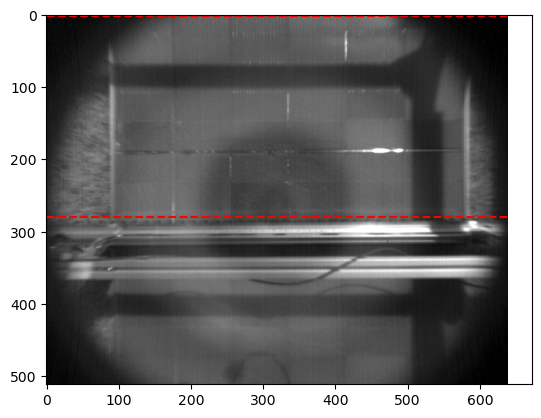

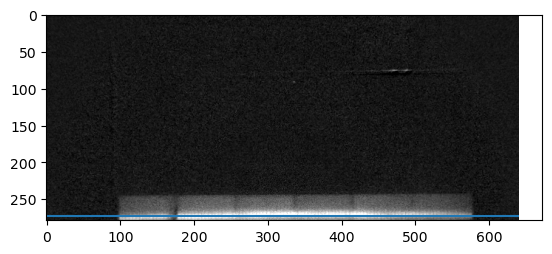

In [6]:
mask = np.zeros_like(scan[0], dtype=np.bool_)
mask_h_lower = 1
mask_h_upper = 280
# mask_v_lower = 100
# mask_v_upper = 580
mask[mask_h_lower:mask_h_upper, :] = True

index = 498
plt.imshow(stretch(scan[peaks[index]]), cmap="gray")
plt.hlines([mask_h_lower, mask_h_upper], xmin=0, xmax=640, color="red", linestyle="--")
plt.show()

peak_frames = scan[peaks][:,mask].reshape((len(peaks),-1,640)).astype(np.float32)
valley_frames = scan[valleys][:,mask].reshape((len(peaks),-1,640)).astype(np.float32)
plt.imshow(stretch(peak_frames[200]-valley_frames[200]), cmap="gray")
plt.hlines(273, 0, 640)

In [7]:
def get_offsets(frames):
    txs = [0]
    tys = [0]
    prev = frames[0]
    hann = cv2.createHanningWindow(prev.shape[::-1], cv2.CV_32F)
    for frame in frames[1:]:
        (tx,ty), _ = cv2.phaseCorrelate(prev, frame, window=hann)
        txs.append(tx)
        tys.append(ty)
        prev = frame

    tys = np.cumsum(tys)
    txs = np.cumsum(txs)
    return txs, tys

def get_frame_weights(tys):
    A = int(tys.max())+1

    weights = 1-np.abs(np.arange(0,A).reshape(-1,1) - tys)
    weights[weights<0] = 0

    return weights

def stitch_frames(frames, line):
    txs,tys = get_offsets(frames)
    weights = get_frame_weights(tys)
    return np.dot(weights,frames[:,line]) / (np.sum(weights,axis=1).reshape((-1,1))+1E-5)

In [8]:
L = len(peaks)
lom = 272
SL = scan[peaks,lom]
BL = scan[valleys,lom]

peak_stitch = stitch_frames(peak_frames, lom)
valley_stitch = stitch_frames(valley_frames, lom)



In [9]:
extrema = np.empty(2*len(peaks), dtype=peaks.dtype)
print(extrema.shape)
extrema[::2] = peaks
extrema[1::2] = valleys

alternating_frames = scan[extrema][:,mask].reshape((len(extrema),-1,640)).astype(np.float32)
txs, tys = get_offsets(alternating_frames)

(1000,)


Version 1


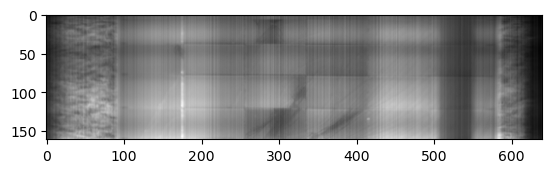

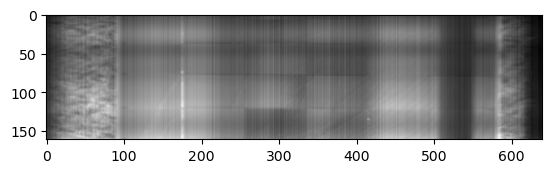

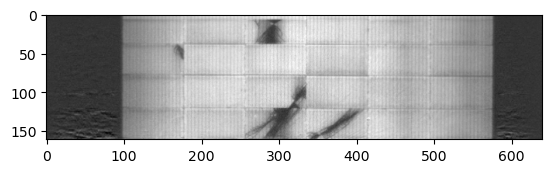

Version 2


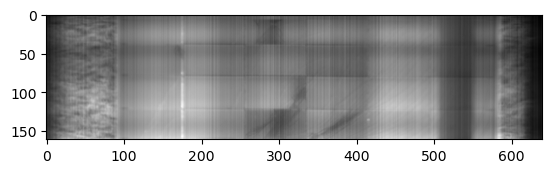

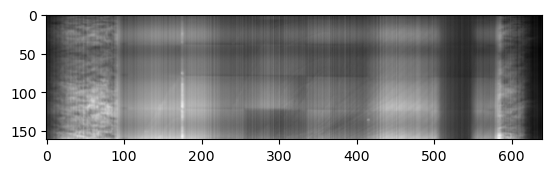

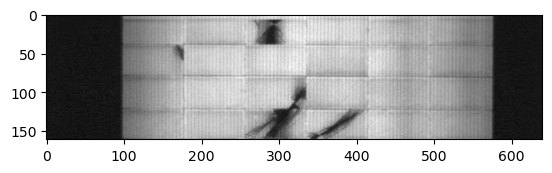

In [10]:
weights = get_frame_weights(tys)
weights_peaks = weights[:,::2]
weights_valleys = weights[:,1::2]

peak_stitch_v2 = np.dot(weights_peaks,peak_frames[:,lom]) / (np.sum(weights_peaks,axis=1).reshape((-1,1))+1E-5)
valley_stitch_v2 = np.dot(weights_valleys,valley_frames[:,lom]) / (np.sum(weights_valleys,axis=1).reshape((-1,1))+1E-5)

def plotter(peak, valley):
    plt.imshow(peak, cmap="gray")
    plt.show()

    plt.imshow(valley, cmap="gray")
    plt.show()

    plt.imshow(peak-valley, cmap="gray")
    plt.show()

print("Version 1")
plotter(peak_stitch, valley_stitch)

print("Version 2")
plotter(peak_stitch_v2, valley_stitch_v2)

In [11]:
window = cv2.createHanningWindow(peak_stitch.shape[::-1], cv2.CV_64F)
(tx,ty),_ = cv2.phaseCorrelate(peak_stitch, valley_stitch, window=window)
print(tx,ty)

-0.06373610825573905 -0.034185692992565464


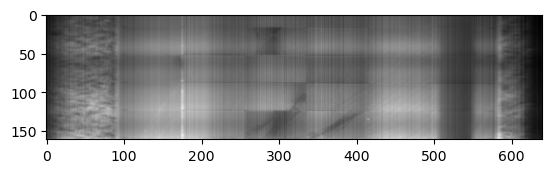

In [12]:
plt.imshow(cv2.resize(SL, (640,peak_stitch.shape[0])),cmap="gray")
plt.show()